In [ ]:
# Dataset link
# https://www.kaggle.com/datasets/akram24/social-network-ads
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].to_numpy()
y = dataset.iloc[:, -1].to_numpy()


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [34]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"C": [0.25, 0.5, 0.75, 1], "kernel": ["linear"]},
    {
        "C": [0.25, 0.5, 0.75, 1],
        "kernel": ["rbf"],
        "gamma": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    },
]

grid_search = GridSearchCV(
    estimator=SVC(random_state=0),
    param_grid=param_grid,
    cv=10,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

,estimator,SVC(random_state=0)
,param_grid,"[{'C': [0.25, 0.5, ...], 'kernel': ['linear']}, {'C': [0.25, 0.5, ...], 'gamma': [0.1, 0.2, ...], 'kernel': ['rbf']}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.5


In [35]:
from sklearn.metrics import confusion_matrix, accuracy_score


best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Best Params:", grid_search.best_params_)


Confusion Matrix:
 [[64  4]
 [ 3 29]]
Accuracy: 0.93
Best Params: {'C': 0.5, 'gamma': 0.6, 'kernel': 'rbf'}


In [36]:
from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=10
)

print(accuracies)
print("CV Accuracy", accuracies.mean()*100)
print("CV Std", accuracies.std()*100)


[0.8        0.96666667 0.83333333 0.96666667 0.86666667 0.86666667
 0.9        0.93333333 1.         0.93333333]
CV Accuracy 90.66666666666666
CV Std 6.110100926607785


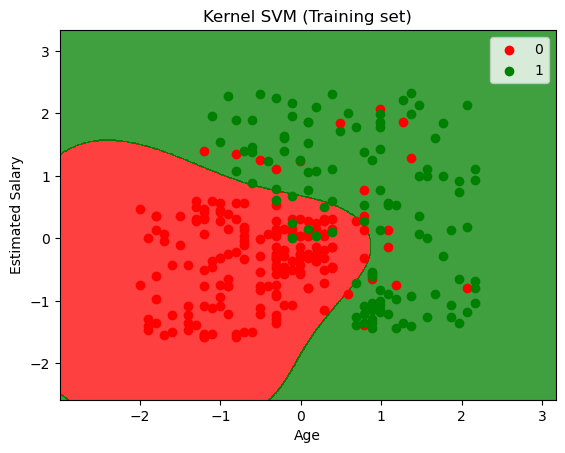

In [ ]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train
x1 = np.linspace(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 500)
x2 = np.linspace(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 500)

X1, X2 = np.meshgrid(x1, x2)
plt.contourf(
    X1,
    X2,
    best_model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(("red", "green")),
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1], c=["red", "green"][i], label=j
    )
plt.title("Kernel SVM")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.legend()
plt.show()